<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
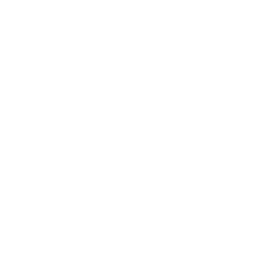
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analýza vzorců hlasování ve volebních okrscích</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Veřejná správa / Volební statistika &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Shrnutí

Tato analýza zkoumá, zda se stranická příslušnost systematicky liší podle typu okrsku (městský, příměstský, venkovský) v simulovaném souboru krajských voleb o 100 okrscích. Protože je několik buněk tabulky strana × typ řídkých — nejmenší kontingenční buňky obsahují jen jeden nebo dva okrsky s očekávanými četnostmi pod pět — je celkový Pearsonův chí-kvadrát test obecné asociace nedostatečně silný a nespolehlivý. Doplňujeme jej proto **Cochranovým-Armitageovým testem trendu**, cíleným testem s jedním stupněm volnosti, který využívá přirozeného uspořádání od městských po venkovské okrsky a klade přesnější otázku: klesá podpora strany A monotónně podél tohoto gradientu? Test trendu uvádí přesnou (exaktní) p-hodnotu, což je vhodná inference při malých četnostech buněk. Kontrast mezi oběma testy je analytickým jádrem tohoto příkladu: obecný test asociace může přehlédnout skutečný směrový vzorec, který uspořádaný test trendu odhalí.


## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Záznamy na úrovni okrsku, jeden řádek na okrsek, s typem okrsku, okresem a vítěznou stranou | 100 |

Prostředí běží v nelicencovaném režimu, který omezuje výstup na 100 pozorování; analýza je navržena kolem tohoto vzorku na úrovni okrsku, takže kontingenční buňky jsou skutečně malé a přesný test trendu je přirozeným nástrojem.


---

In [1]:
/* --------------------------------------------------------
   Generovani syntetickych dat hlasovani na urovni okrsku
   Male pocty v venkovskych okrscich pro demonstraci
   potreby presnych testu
   -------------------------------------------------------- */
data work.precinct_votes;
    CALL streaminit(42);
    POLE county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    DÉLKA precinct_type $16 party $12;
    OPAKUJ precinct_seq = 1 TO 500;
        precinct_id = cat('PCT-', ZAPSAT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Priradit typ okrsku s vahou */
        type_prob = rand('uniform');
        KDYŽ type_prob < 0.30 PAK precinct_type = 'MĚSTSKÝ';
        JINAK KDYŽ type_prob < 0.65 PAK precinct_type = 'PŘÍMĚSTSKÝ';
        JINAK precinct_type = 'VENKOVSKÝ';
        /* Priradit stranu s rozlozenim zavislym na typu */
        party_prob = rand('uniform');
        KDYŽ precinct_type = 'MĚSTSKÝ' PAK OPAKUJ;
            KDYŽ party_prob < 0.55 PAK party = 'STRANA_A';
            JINAK KDYŽ party_prob < 0.80 PAK party = 'STRANA_B';
            JINAK KDYŽ party_prob < 0.92 PAK party = 'STRANA_C';
            JINAK party = 'NEZÁVISLÝ';
        KONEC;
        JINAK KDYŽ precinct_type = 'PŘÍMĚSTSKÝ' PAK OPAKUJ;
            KDYŽ party_prob < 0.40 PAK party = 'STRANA_A';
            JINAK KDYŽ party_prob < 0.75 PAK party = 'STRANA_B';
            JINAK KDYŽ party_prob < 0.88 PAK party = 'STRANA_C';
            JINAK party = 'NEZÁVISLÝ';
        KONEC;
        JINAK OPAKUJ; /* VENKOVSKY - mensi buňky pro mensinove strany */
            KDYŽ party_prob < 0.25 PAK party = 'STRANA_A';
            JINAK KDYŽ party_prob < 0.70 PAK party = 'STRANA_B';
            JINAK KDYŽ party_prob < 0.85 PAK party = 'STRANA_C';
            JINAK party = 'NEZÁVISLÝ';
        KONEC;
        /* Pocet hlasu se lisi podle typu okrsku */
        KDYŽ precinct_type = 'MĚSTSKÝ' PAK
            vote_count = int(rand('normal', 120, 40));
        JINAK KDYŽ precinct_type = 'PŘÍMĚSTSKÝ' PAK
            vote_count = int(rand('normal', 80, 25));
        JINAK
            vote_count = int(rand('normal', 25, 12));
        KDYŽ vote_count < 1 PAK vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        VÝSTUP;
    KONEC;
    ODSTRANIT precinct_seq county_idx type_prob party_prob;
SPUSTIT;


NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

                                                   The FREQ Procedure

Typ okrsku        Frequency    Percent
---------------------------------------
MĚSTSKÝ                  29     29.00
PŘÍMĚSTSKÝ               37     37.00
VENKOVSKÝ                34     34.00

Strana         Frequency    Percent
------------------------------------
NEZÁVISLÝ              9      9.00
STRANA_A              45     45.00
STRANA_B              34     34.00
STRANA_C              12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


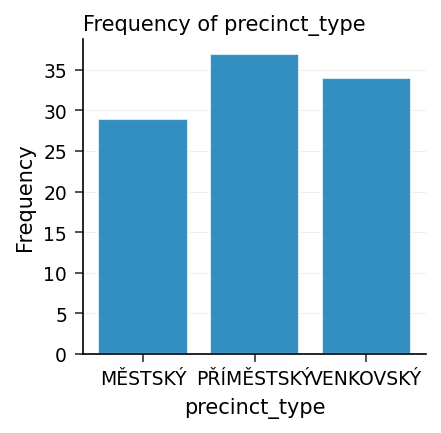

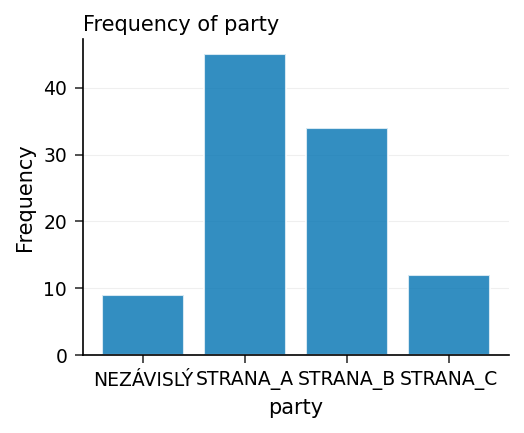

In [2]:
/* --------------------------------------------------------
   Zakladni rozlozeni typu okrsku a stran
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    ŠTÍTEK precinct_type='Typ okrsku' party='Strana';
SPUSTIT;

---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


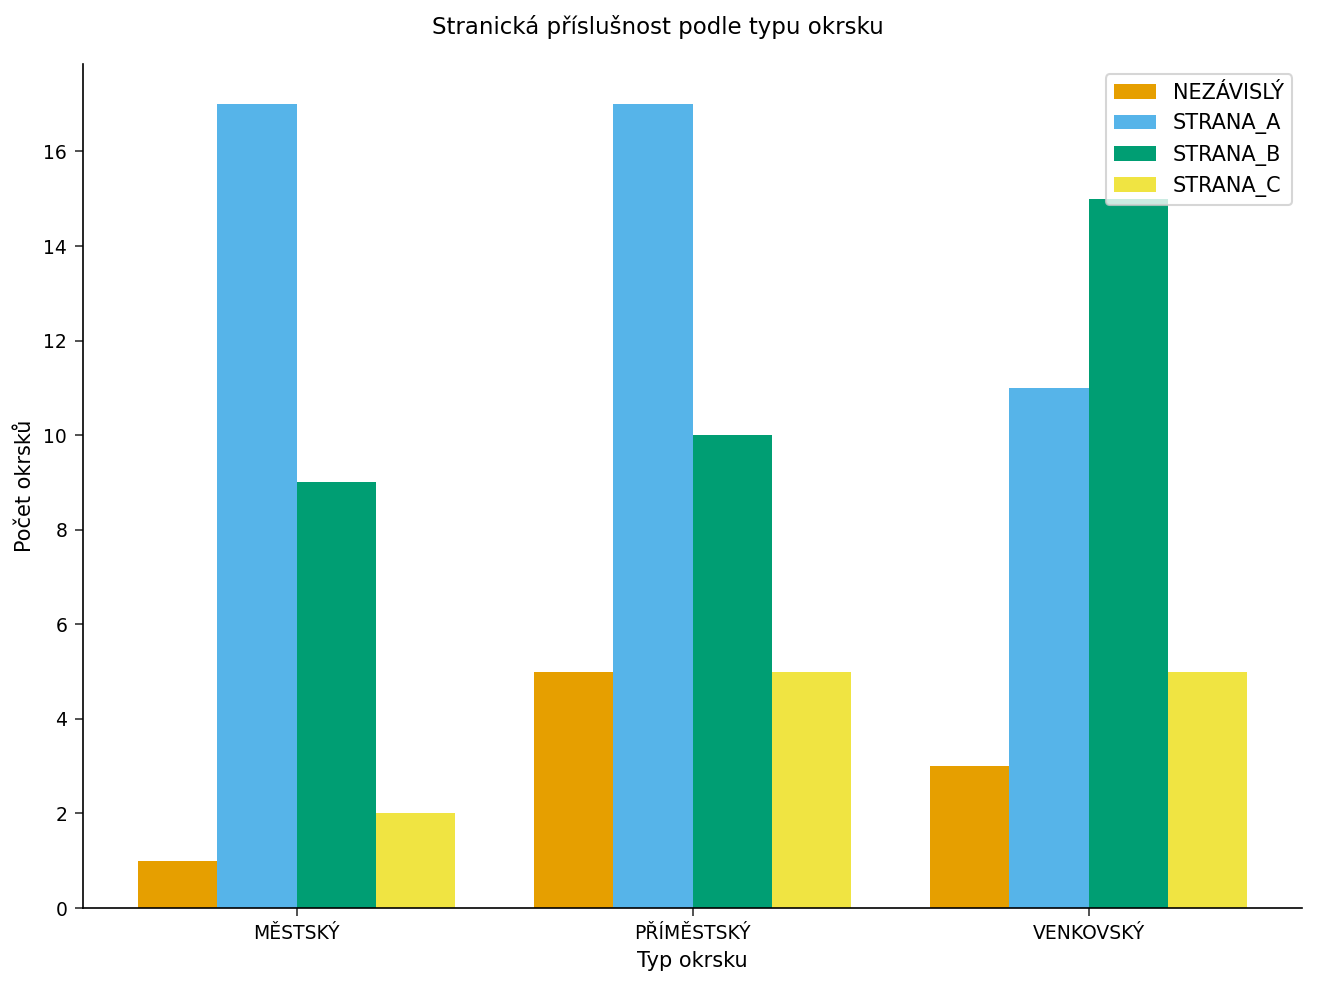

In [3]:
/* --------------------------------------------------------
   Stranicka prislusnost podle typu okrsku (pocty okrsku)
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=ČETNOSTI;
    XAXIS ŠTÍTEK='Typ okrsku';
    YAXIS ŠTÍTEK='Počet okrsků';
    NÁZEV 'Stranická příslušnost podle typu okrsku';
SPUSTIT;

---

                           Typ okrsku podle strany: křížová tabulace s očekávanými četnostmi                            

                                                   The FREQ Procedure

Table of Typ okrsku by Strana

Typ okrsku     |  NEZÁVISLÝ |   STRANA_A |   STRANA_B |   STRANA_C |       Total
---------------+------------+------------+------------+------------+------------
MĚSTSKÝ        |          1 |         17 |          9 |          2 |          29
               |       1.00 |      17.00 |       9.00 |       2.00 |       29.00
               |       2.61 |      13.05 |       9.86 |       3.48 |            
               |       3.45 |      58.62 |      31.03 |       6.90 |      100.00
               |      11.11 |      37.78 |      26.47 |      16.67 |       29.00
---------------+------------+------------+------------+------------+------------
PŘÍMĚSTSKÝ     |          5 |         17 |         10 |          5 |          37
               |       5.00 |      17.00 |     


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


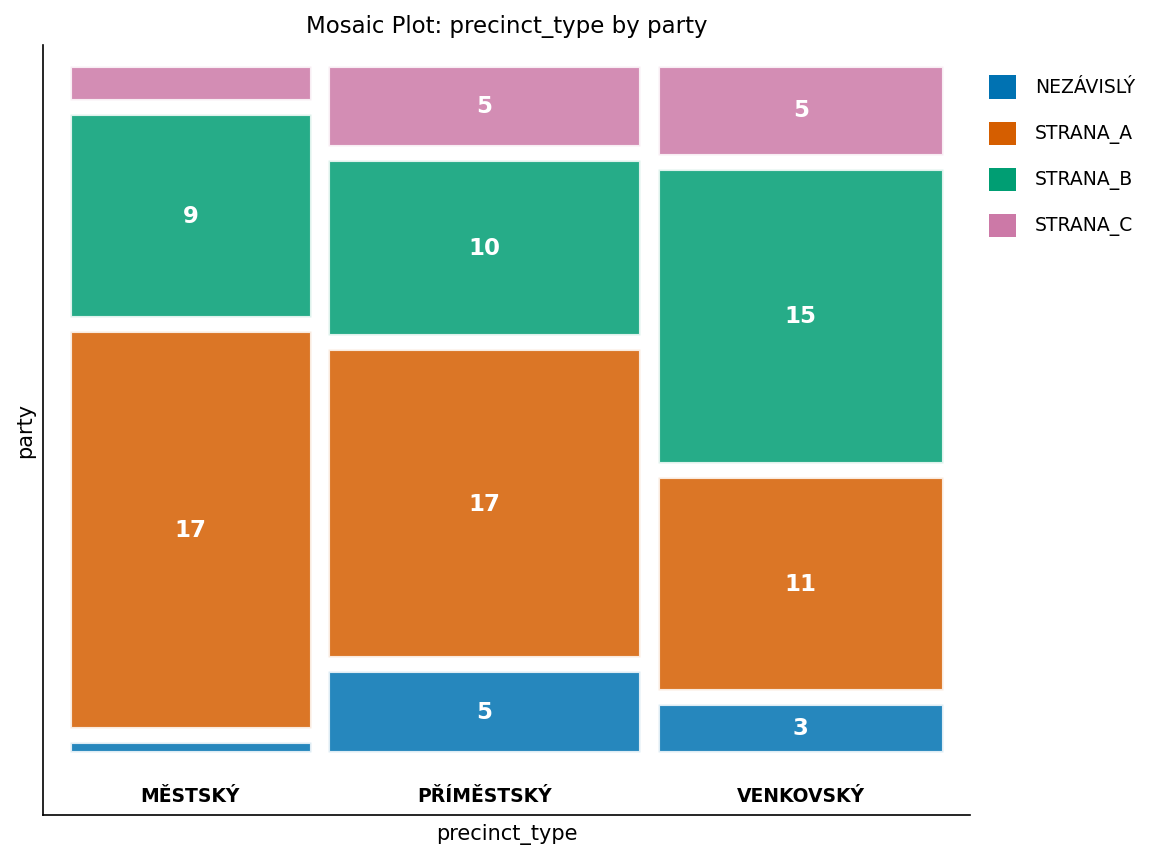

In [4]:
/* --------------------------------------------------------
   Krizova tabulka typ okrsku x strana.
   Pozadovat OCEKAVANE pocty, aby byly viditelne ridke bunky,
   plus asymptoticky Pearsonuv chi-kvadrat test obecne
   asociace. Vsimnete si malych ocekavanych poctu ve sloupcich
   NEZAVISLY a STRANA_C -- to je signal, ze usporadany,
   presny test trendu je lepsim inferencnim nastrojem.
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    ŠTÍTEK precinct_type='Typ okrsku' party='Strana';
    NÁZEV 'Typ okrsku podle strany: křížová tabulace s očekávanými četnostmi';
SPUSTIT;

                      Cochranův-Armitageův test trendu: podpora strany A napříč gradientem okrsků                       

                                                   The FREQ Procedure

Table of Pořadí typu okrsku by Podpora strany A

Pořadí typu okrsku   |         0 |         1 |      Total
---------------------+-----------+-----------+-----------
1                    |        12 |        17 |         29
                     |     12.00 |     17.00 |      29.00
                     |     41.38 |     58.62 |     100.00
                     |     21.82 |     37.78 |      29.00
---------------------+-----------+-----------+-----------
2                    |        20 |        17 |         37
                     |     20.00 |     17.00 |      37.00
                     |     54.05 |     45.95 |     100.00
                     |     36.36 |     37.78 |      37.00
---------------------+-----------+-----------+-----------
3                    |        23 |        11 |         34
    


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


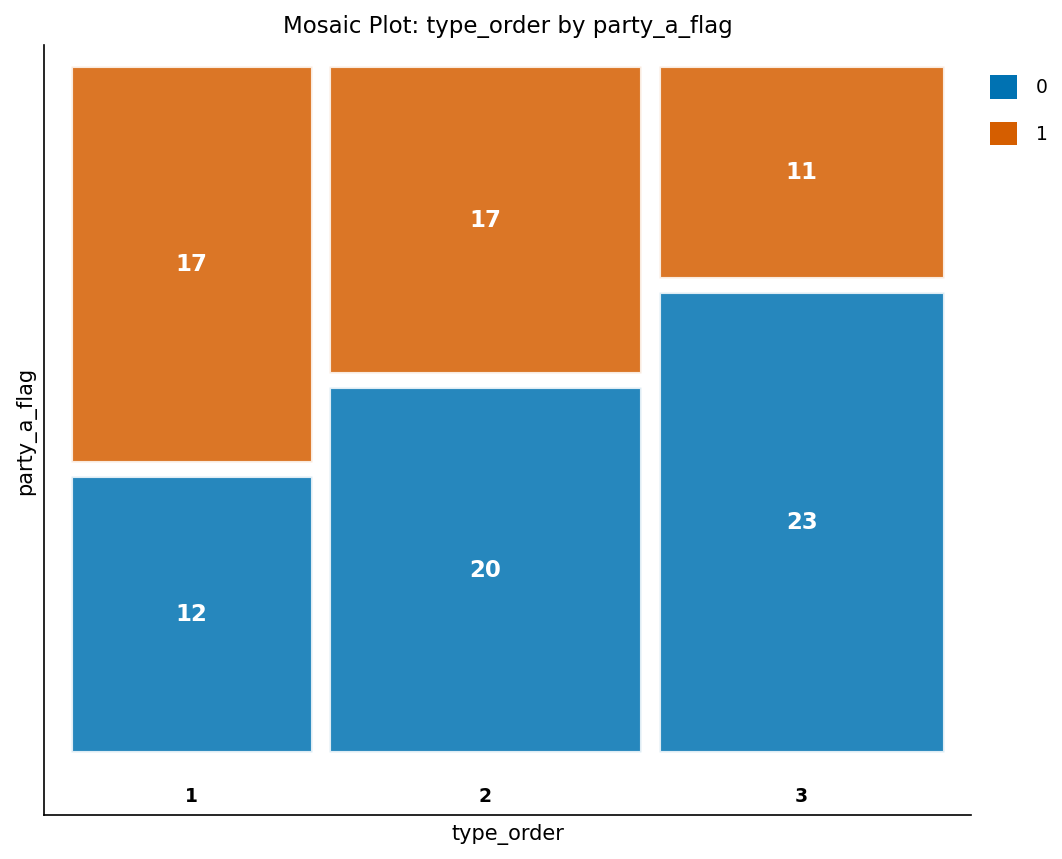

In [5]:
/* --------------------------------------------------------
   Cochranuv-Armitageuv test trendu. Prekodovat typ okrsku
   na ordinalni skore (1=Mestsky, 2=Primestsky, 3=Venkovsky)
   a otestovat, zda podpora strany A vykazuje monotonni trend
   napric gradientem. EXACT TREND vyzada presnou p-hodnotu,
   coz je vhodne vzhledem k malym poctum bunek.
   -------------------------------------------------------- */
data work.precinct_ordinal;
    NASTAVIT work.precinct_votes;
    /* Ordinalni kodovani: 1=Mestsky, 2=Primestsky, 3=Venkovsky */
    KDYŽ precinct_type = 'MĚSTSKÝ' PAK type_order = 1;
    JINAK KDYŽ precinct_type = 'PŘÍMĚSTSKÝ' PAK type_order = 2;
    JINAK type_order = 3;
    /* Binarni vysledek: strana A vs. vsechny ostatni prislusnosti */
    party_a_flag = (party = 'STRANA_A');
SPUSTIT;

PROCEDURA ČETNOSTI data=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    ŠTÍTEK type_order='Pořadí typu okrsku' party_a_flag='Podpora strany A';
    NÁZEV 'Cochranův-Armitageův test trendu: podpora strany A napříč gradientem okrsků';
SPUSTIT;

                                          Rozložení typů okrsků v rámci okresu                                          

                                                   The FREQ Procedure

Table of Okres by Typ okrsku

Okres     |       MĚSTSKÝ |    PŘÍMĚSTSKÝ |     VENKOVSKÝ |          Total
----------+---------------+---------------+---------------+---------------
ADAMS     |             4 |            10 |             5 |             19
          |          4.00 |         10.00 |          5.00 |          19.00
          |         21.05 |         52.63 |         26.32 |         100.00
          |         13.79 |         27.03 |         14.71 |          19.00
----------+---------------+---------------+---------------+---------------
HAMILTON  |             7 |             7 |             7 |             21
          |          7.00 |          7.00 |          7.00 |          21.00
          |         33.33 |         33.33 |         33.33 |         100.00
          |         24.14 |


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


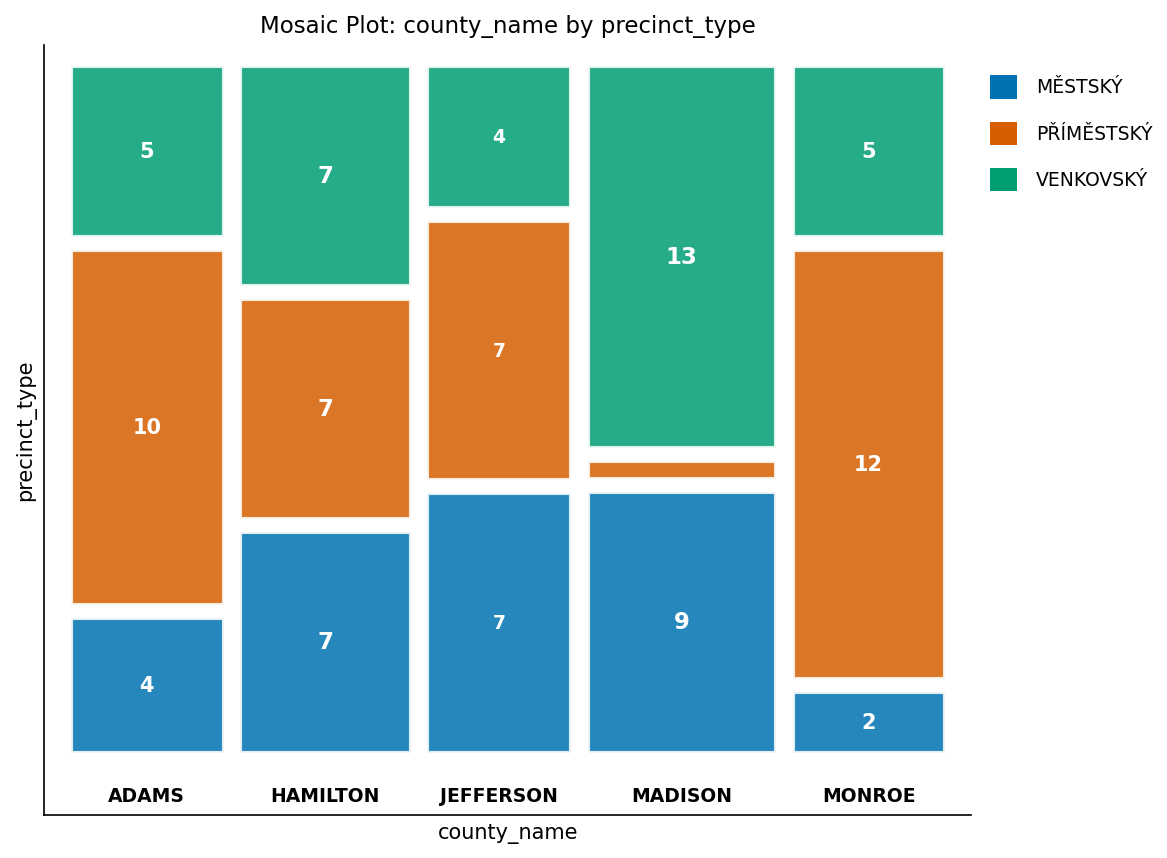

In [6]:
/* --------------------------------------------------------
   Pohled na urovni okresu: jak se mix mestsky/primestsky/
   venkovsky lisi napric peti okresy. Tento pohled dava
   kontext vysledku trendu -- gradient okrsku je pritomen
   v kazdem okrese, ale jeho slozeni se lisi.
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    ŠTÍTEK county_name='Okres' precinct_type='Typ okrsku';
    NÁZEV 'Rozložení typů okrsků v rámci okresu';
SPUSTIT;

---

### Interpretace

Napříč 100 okrsky drží strana A celkovou většinu (45 okrsků), následuje strana B (34), strana C (12) a nezávislí (9). Křížová tabulace ukazuje, že podíl strany A sleduje jasný gradient od městských k venkovským okrskům: tvoří 58,6 % městských okrsků, 46,0 % příměstských okrsků a 32,4 % venkovských okrsků, zatímco strana B se pohybuje opačným směrem a stoupá z 31,0 % ve městě na 44,1 % na venkově.

Celkový Pearsonův chí-kvadrát test obecné asociace **není** statisticky významný (chí-kvadrát = 6,78, 6 stupňů volnosti, p = 0,3418; Cramérovo V = 0,18). Tento výsledek je také křehký: zobrazení očekávaných četností odhaluje několik buněk pod pět — například sloupec Nezávislí má očekávané četnosti 3,06, 3,33 a 2,61 a městských nezávislých je jen jeden okrsek — takže velkovzorková aproximace chí-kvadrátu je zde nespolehlivá.

Cochranův-Armitageův test trendu otázku zpřesňuje pomocí ordinálního skórování městský-příměstský-venkovský. Odhalí monotónní pokles podpory strany A, který celkový test přehlédne: chí-kvadrát trendu = 4,38 s asymptotickým Pr > ChiSq = 0,0363 a **exaktní Pr >= |Z| = 0,0431**, významné na hladině 0,05. Toto je analytický přínos — cílený, přesný test s jedním stupněm volnosti odhalí skutečný směrový signál, který obecný test asociace o 6 stupních volnosti, oslabený řídkými buňkami, neodhalí.

Pohled na úrovni okresu potvrzuje, že rozdělení městský/příměstský/venkovský je přítomno ve všech pěti okresech, i když se skladba liší: Madison je nejvíce venkovský (13 z 23 okrsků venkovských), zatímco Monroe je nejvíce příměstský (12 z 19). Pro posouzení dopadu redistrikce je poznatek ten, že změny hranic posouvající okrsky podél osy město-venkov by měřitelně změnily stranické složení a že tento geografický trend nejlépe dokládá přesný test trendu, nikoli celkový chí-kvadrát.


---

                                          Rozložení typů okrsků v rámci okresu                                          

                                                   The FREQ Procedure

Table of Typ okrsku by Strana

Typ okrsku     |  NEZÁVISLÝ |   STRANA_A |   STRANA_B |   STRANA_C |       Total
---------------+------------+------------+------------+------------+------------
MĚSTSKÝ        |          1 |         17 |          9 |          2 |          29
               |       1.00 |      17.00 |       9.00 |       2.00 |       29.00
               |       3.45 |      58.62 |      31.03 |       6.90 |      100.00
               |      11.11 |      37.78 |      26.47 |      16.67 |       29.00
---------------+------------+------------+------------+------------+------------
PŘÍMĚSTSKÝ     |          5 |         17 |         10 |          5 |          37
               |       5.00 |      17.00 |      10.00 |       5.00 |       37.00
               |      13.51 |      45.95 |     


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


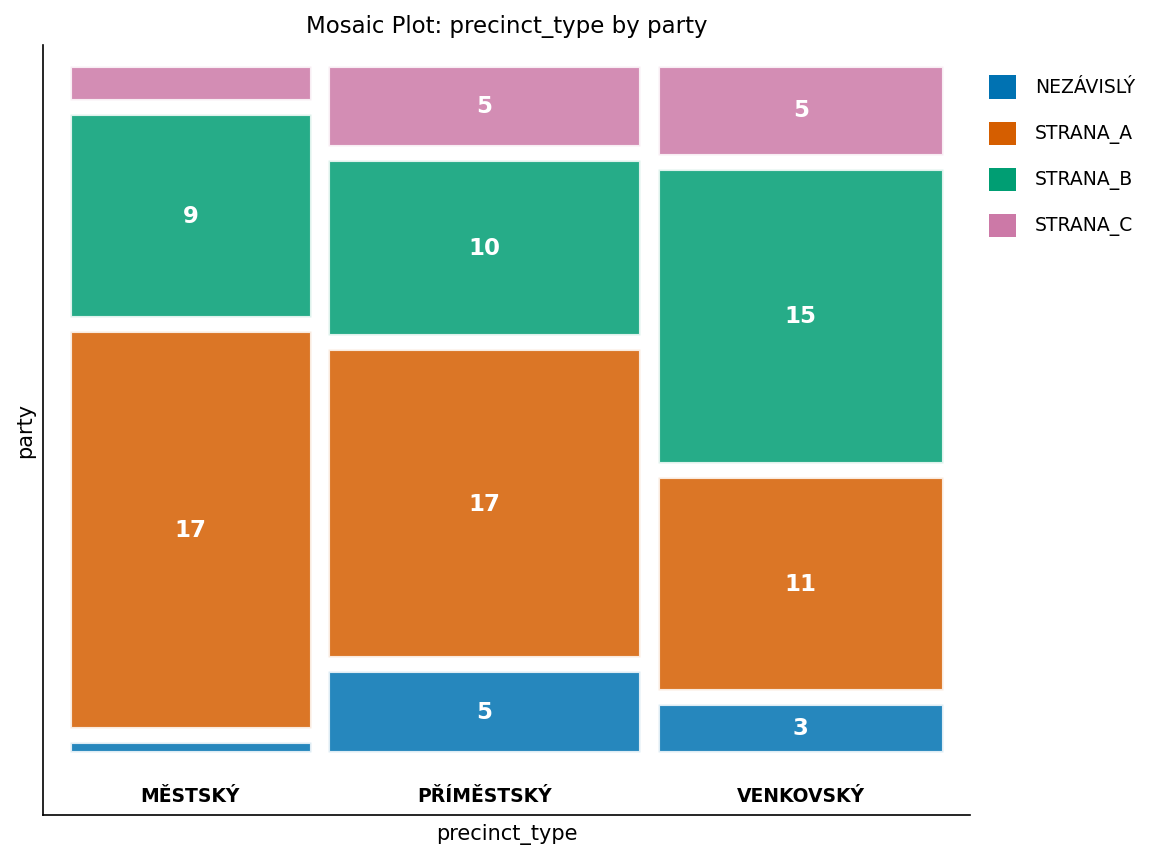

In [7]:
/* --------------------------------------------------------
   Export souhrnu typ okrsku x strana pro navazujici
   posouzeni dopadu redistrikce.
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    ŠTÍTEK precinct_type='Typ okrsku' party='Strana';
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
SPUSTIT;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>